# Marketing Campaign Analysis
## Phase 4 — Customer lifetime value & response propensity

**Data source:** marketing_db (PostgreSQL)
**Goal:** Predict customer value (regression) and campaign response propensity (classification), then combine both into a targeting priority matrix. The regression answers "how much will this customer spend?" and the classifier answers "will they respond to the next campaign?".

### What this phase does
- Use SQL to segment customers into 3 CLV tiers and profile each tier
- Train and evaluate **3 regression models** to predict total spend, using only behaviour-free features (no purchase counts, no per-category spend)
- Train and evaluate **3 classification models** to predict campaign response, using `total_hist_campaigns_accepted` (leakage-safe) as the strongest signal
- Combine CLV tier + response probability into a targeting priority matrix
- Pick the best model in each task by per-class behaviour, not by headline metric alone

### Leakage prevention — explicit
**CLV regression target:** `total_spend`. The following features are **excluded** because they are direct proxies for the target:
- All individual category spend columns (`mnt_wines`, `mnt_fruits`, ...) — they sum to `total_spend`.
- All purchase count columns (`num_web_purchases`, `num_catalog_purchases`, `num_store_purchases`, `num_deals_purchases`, `total_purchases`) — these measure the same behaviour as spend, just in count units instead of dollars. Including them would inflate R² without producing real predictive ability.
- `avg_spend_per_purchase` — derived from `total_spend`.

**Classification target:** `response`. The feature `total_hist_campaigns_accepted` sums only `AcceptedCmp1`–`AcceptedCmp5` (the 5 historical campaigns); `response` itself is never used as a feature.

### Sample bias note (from Phase 2)
24 customers with missing income were dropped during cleaning. Those customers had a 4.2% response rate vs 15% for the rest. The classifier here is therefore calibrated on a sample slightly tilted toward more responsive customers — real-world response probabilities for genuinely income-unknown customers may be lower than the model predicts.

---
## 1. Import libraries & connect to database

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import getpass
import warnings
from pathlib import Path

from sqlalchemy import create_engine, text

# Sklearn — preprocessing, models, evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, recall_score,
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Locate the repo root portably by walking up from the current working
# directory until the 'data' folder is found, so the notebook runs on any
# machine and from any subfolder.
def find_project_root(marker='data'):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not find project root: no '{marker}/' folder above {Path.cwd()}. "
        "Run this notebook from inside the cloned repository."
    )

PROJECT_ROOT   = find_project_root()
PROCESSED_PATH = str(PROJECT_ROOT / 'data' / 'processed') + os.sep
DOCS_PATH      = str(PROJECT_ROOT / 'docs')
SQL_PATH       = str(PROJECT_ROOT / 'sql' / 'queries')
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(DOCS_PATH, exist_ok=True)
os.makedirs(SQL_PATH, exist_ok=True)

# PostgreSQL — local trust auth
username = getpass.getuser()
DB_URL   = f'postgresql+psycopg2://{username}@localhost:5432/marketing_db'
engine   = create_engine(DB_URL, future=True)

# Single seed for all stochastic operations — reproducibility
RANDOM_STATE = 42

# Helper — runs a SQL query, returns a DataFrame, saves the query for audit
def run_query(sql, name=None):
    if name:
        path = os.path.join(SQL_PATH, f'{name}.sql')
        with open(path, 'w') as f:
            f.write(sql.strip())
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

test = run_query('SELECT COUNT(*) AS n FROM customers')
print(f'Connected ✅ — {test["n"].values[0]:,} customers in database')

Connected ✅ — 2,212 customers in database


---
## 2. CLV segmentation via SQL
`NTILE(3)` splits customers into three equal-size value tiers ordered by total spend. The query then computes the average profile of each tier so the business segmentation has a human-readable shape before we model anything.

In [2]:
sql_clv_tiers = '''
WITH customer_tiers AS (
    SELECT
        s.customer_id,
        s.total_spend,
        NTILE(3) OVER (ORDER BY s.total_spend) AS clv_tier
    FROM spending s
)
SELECT
    CASE ct.clv_tier
        WHEN 1 THEN 'Low value'
        WHEN 2 THEN 'Mid value'
        WHEN 3 THEN 'High value'
    END                                                      AS clv_tier,
    COUNT(*)                                                 AS customer_count,
    ROUND(MIN(ct.total_spend)::NUMERIC, 0)                   AS min_spend,
    ROUND(MAX(ct.total_spend)::NUMERIC, 0)                   AS max_spend,
    ROUND(AVG(ct.total_spend)::NUMERIC, 0)                   AS avg_spend,
    ROUND(AVG(cu.income)::NUMERIC, 0)                        AS avg_income,
    ROUND(AVG(cu.age)::NUMERIC, 1)                           AS avg_age,
    ROUND(AVG(cu.recency)::NUMERIC, 1)                       AS avg_recency,
    ROUND(AVG(ch.total_purchases)::NUMERIC, 1)               AS avg_purchases,
    ROUND(AVG(ca.total_hist_campaigns_accepted)::NUMERIC, 2) AS avg_hist_campaigns
FROM customer_tiers ct
JOIN customers cu ON ct.customer_id = cu.customer_id
JOIN channels  ch ON ct.customer_id = ch.customer_id
JOIN campaigns ca ON ct.customer_id = ca.customer_id
GROUP BY ct.clv_tier
ORDER BY ct.clv_tier
'''

clv_tiers = run_query(sql_clv_tiers, 'clv_tier_profiles')
print('CLV tier profiles:')
print(clv_tiers.to_string(index=False))

CLV tier profiles:
  clv_tier  customer_count  min_spend  max_spend  avg_spend  avg_income  avg_age  avg_recency  avg_purchases  avg_hist_campaigns
 Low value             738        5.0      116.0       51.0     31888.0     41.8         48.6            6.5                0.08
 Mid value             737      116.0      834.0      416.0     50978.0     46.5         48.3           16.3                0.17
High value             737      835.0     2525.0     1355.0     73038.0     46.9         50.1           21.9                0.64


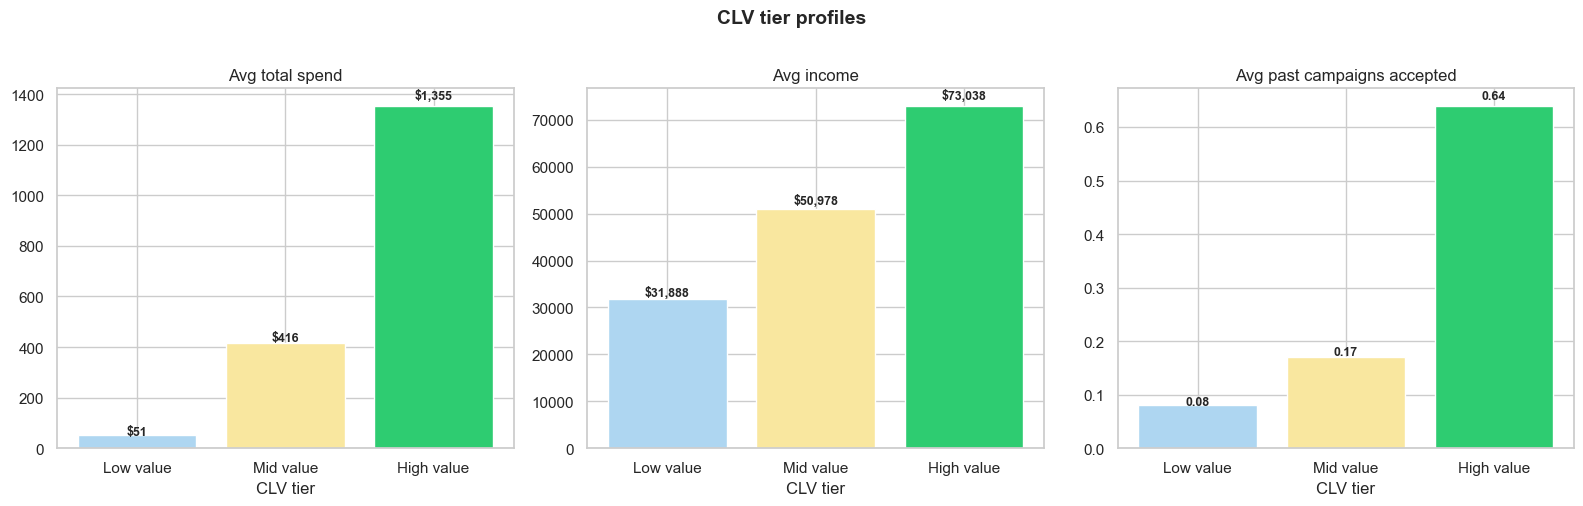

In [3]:
# Visualise the three tier profiles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
tiers = clv_tiers['clv_tier'].tolist()
colors = ['#AED6F1', '#F9E79F', '#2ECC71']

for ax, col, title, prefix in zip(
    axes,
    ['avg_spend', 'avg_income', 'avg_hist_campaigns'],
    ['Avg total spend', 'Avg income', 'Avg past campaigns accepted'],
    ['$', '$', '']
):
    vals = clv_tiers[col].astype(float).tolist()
    bars = ax.bar(tiers, vals, color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('CLV tier')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{prefix}{val:,.2f}' if val % 1 else f'{prefix}{int(val):,}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('CLV tier profiles', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p4_clv_tier_profiles.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Feature extraction
Pull the full feature set in one SQL query joining all four tables. Encoding and feature selection happen in Python afterwards.

In [4]:
sql_features = '''
SELECT
    -- Identity & target
    cu.customer_id,
    s.total_spend,

    -- Demographics
    cu.age,
    cu.income,
    cu.education,
    cu.marital_status,
    cu.total_children,
    cu.has_children,
    cu.tenure_days,
    cu.recency,

    -- Web visit behaviour (NOT a spend proxy — measures intent, not purchases)
    ch.num_web_visits_month,

    -- Historical campaign behaviour (leakage-safe — excludes response)
    ca.total_hist_campaigns_accepted,

    -- Classification target
    ca.response,

    -- Behavioural proxies — present here for the CLASSIFIER only, not the CLV regression
    -- (We will split features per task below)
    ch.num_web_purchases,
    ch.num_store_purchases,
    ch.num_catalog_purchases,
    ch.num_deals_purchases,
    ch.total_purchases
FROM customers cu
JOIN channels  ch ON cu.customer_id = ch.customer_id
JOIN campaigns ca ON cu.customer_id = ca.customer_id
JOIN spending  s  ON cu.customer_id = s.customer_id
'''

df = run_query(sql_features, 'clv_feature_extraction')
print(f'Feature dataset shape: {df.shape}')
print(f'Missing values:        {df.isnull().sum().sum()}')
print(f'\nColumns: {list(df.columns)}')

Feature dataset shape: (2212, 18)
Missing values:        0

Columns: ['customer_id', 'total_spend', 'age', 'income', 'education', 'marital_status', 'total_children', 'has_children', 'tenure_days', 'recency', 'num_web_visits_month', 'total_hist_campaigns_accepted', 'response', 'num_web_purchases', 'num_store_purchases', 'num_catalog_purchases', 'num_deals_purchases', 'total_purchases']


---
## 4. Feature encoding
Both `education` and `marital_status` are nominal — they're not strictly ordered (Undergraduate vs Graduation positioning is debatable). One-hot encoding lets the model learn the actual response/spend patterns without imposing a false ordinal structure.

In [5]:
# One-hot encode education (drop_first avoids multicollinearity)
education_dummies = pd.get_dummies(df['education'], prefix='edu', drop_first=True)

# One-hot encode marital status
marital_dummies = pd.get_dummies(df['marital_status'], prefix='marital', drop_first=True)

df = pd.concat([df, education_dummies, marital_dummies], axis=1)

print('Education one-hot columns:', list(education_dummies.columns))
print('Marital one-hot columns:  ', list(marital_dummies.columns))

Education one-hot columns: ['edu_Graduation', 'edu_Master', 'edu_PhD', 'edu_Undergraduate']
Marital one-hot columns:   ['marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow']


---
## 5. CLV regression — predict total spend
**Features used:** demographics, tenure, recency, web visits, and historical campaign acceptance. Purchase counts and per-category spend are excluded — they are spend behaviour expressed in different units and would create target leakage.

The honest test: can we predict customer value from who they are and how they engage, **without already knowing how much they buy?**

In [6]:
# Strict no-leakage feature set for CLV regression
clv_features = [
    'age', 'income',
    'total_children', 'has_children',
    'tenure_days', 'recency',
    'num_web_visits_month',
    'total_hist_campaigns_accepted',
] + list(education_dummies.columns) + list(marital_dummies.columns)

print(f'CLV regression features ({len(clv_features)}):')
for f in clv_features:
    print(f'  - {f}')

X = df[clv_features].values
y = df['total_spend'].values

# 80/20 split — random_state=42 for reproducibility
# Regression target is continuous so we don't stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Standardise for Linear Regression — tree models don't require it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\nTraining set: {X_train.shape[0]:,} rows')
print(f'Test set:     {X_test.shape[0]:,} rows')

CLV regression features (16):
  - age
  - income
  - total_children
  - has_children
  - tenure_days
  - recency
  - num_web_visits_month
  - total_hist_campaigns_accepted
  - edu_Graduation
  - edu_Master
  - edu_PhD
  - edu_Undergraduate
  - marital_Married
  - marital_Single
  - marital_Together
  - marital_Widow

Training set: 1,769 rows
Test set:     443 rows


In [7]:
# Train all three regression models + a baseline that predicts the mean
# The baseline tells us whether the models add real value or just match the average
models_reg = {
    'Baseline (mean)':   DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

trained_reg = {}
reg_results = []

for name, model in models_reg.items():
    # Linear models use scaled features, tree models use raw
    is_linear = name in ('Baseline (mean)', 'Linear Regression')
    X_tr = X_train_scaled if is_linear else X_train
    X_te = X_test_scaled  if is_linear else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    trained_reg[name] = (model, X_te, preds)
    reg_results.append({
        'Model': name,
        'MAE':   round(mae, 2),
        'RMSE':  round(rmse, 2),
        'R²':    round(r2, 4),
    })

reg_results_df = pd.DataFrame(reg_results)
print('Regression model comparison (lower MAE/RMSE = better, higher R² = better):')
print(reg_results_df.to_string(index=False))

Regression model comparison (lower MAE/RMSE = better, higher R² = better):
            Model    MAE   RMSE      R²
  Baseline (mean) 532.26 622.19 -0.0009
Linear Regression 227.68 322.32  0.7314
    Random Forest 151.58 233.22  0.8594
Gradient Boosting 163.48 251.31  0.8367


### 5a. Diagnostic plots for the best regression model
Evaluation order: (1) actual vs predicted scatter — does the model track the relationship across the full value range? (2) residuals distribution — is error symmetric or biased? (3) MAE / RMSE / R² — the summary numbers, last.

In [8]:
# Pick the best non-baseline model by R²
candidate_reg = reg_results_df[reg_results_df['Model'] != 'Baseline (mean)']
best_reg_name = candidate_reg.loc[candidate_reg['R²'].idxmax(), 'Model']
best_reg_model, X_te_best, best_preds = trained_reg[best_reg_name]
residuals = y_test - best_preds

print(f'Selected regression model: {best_reg_name}')
print(f'  Baseline R²:  {reg_results_df.loc[reg_results_df["Model"]=="Baseline (mean)", "R²"].values[0]:.4f}')
print(f'  Model R²:     {reg_results_df.loc[reg_results_df["Model"]==best_reg_name, "R²"].values[0]:.4f}')
print(f'  Lift over baseline: model explains the variance the baseline cannot.')

Selected regression model: Random Forest
  Baseline R²:  -0.0009
  Model R²:     0.8594
  Lift over baseline: model explains the variance the baseline cannot.


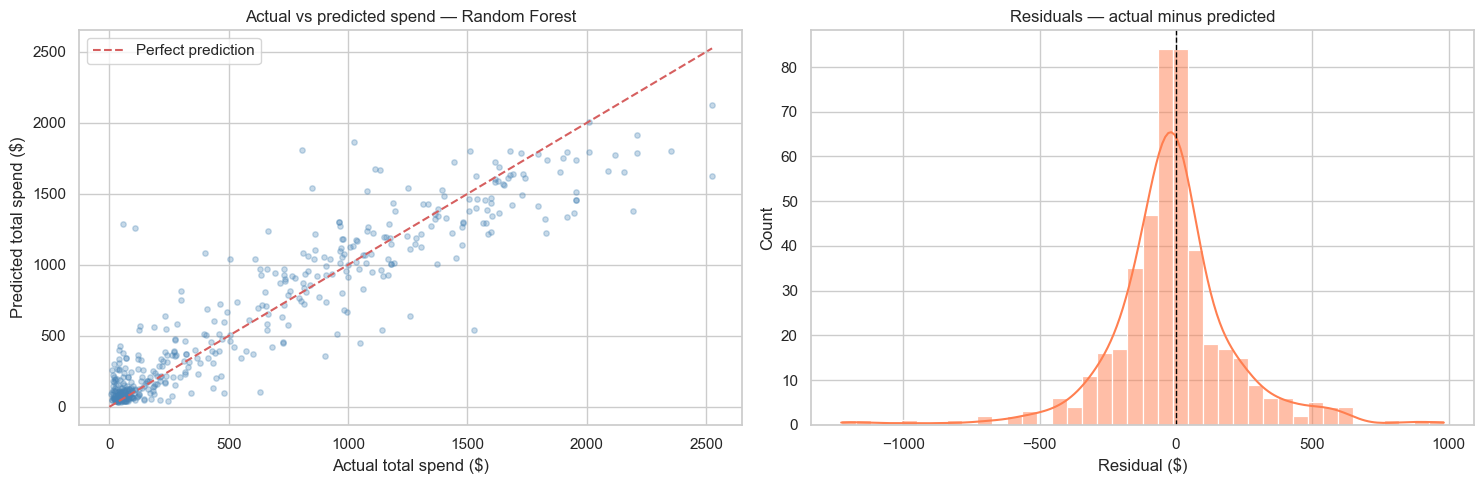


Step 3 — summary metrics:
  Mean residual: $-12.42  (close to 0 = unbiased)
  Residual std:  $232.89


In [9]:
# Diagnostic plots in the correct order
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Step 1 — actual vs predicted scatter
axes[0].scatter(y_test, best_preds, alpha=0.3, color='steelblue', s=15)
max_val = max(y_test.max(), best_preds.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title(f'Actual vs predicted spend — {best_reg_name}', fontsize=12)
axes[0].set_xlabel('Actual total spend ($)')
axes[0].set_ylabel('Predicted total spend ($)')
axes[0].legend()

# Step 2 — residuals distribution
sns.histplot(residuals, bins=40, ax=axes[1], color='coral', kde=True)
axes[1].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Residuals — actual minus predicted', fontsize=12)
axes[1].set_xlabel('Residual ($)')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p4_regression_diagnostics.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStep 3 — summary metrics:')
print(f'  Mean residual: ${residuals.mean():.2f}  (close to 0 = unbiased)')
print(f'  Residual std:  ${residuals.std():.2f}')

---
## 6. CLV feature importance
Feature importance is taken from the actual winning model — not always the same model.

Top features driving CLV (Random Forest feature importance):
                      Feature  Importance
                       income    0.754559
                  tenure_days    0.080560
               total_children    0.027864
                      recency    0.026553
                          age    0.025282
total_hist_campaigns_accepted    0.022312
         num_web_visits_month    0.019653
                 has_children    0.017901
               edu_Graduation    0.004616
                      edu_PhD    0.004446


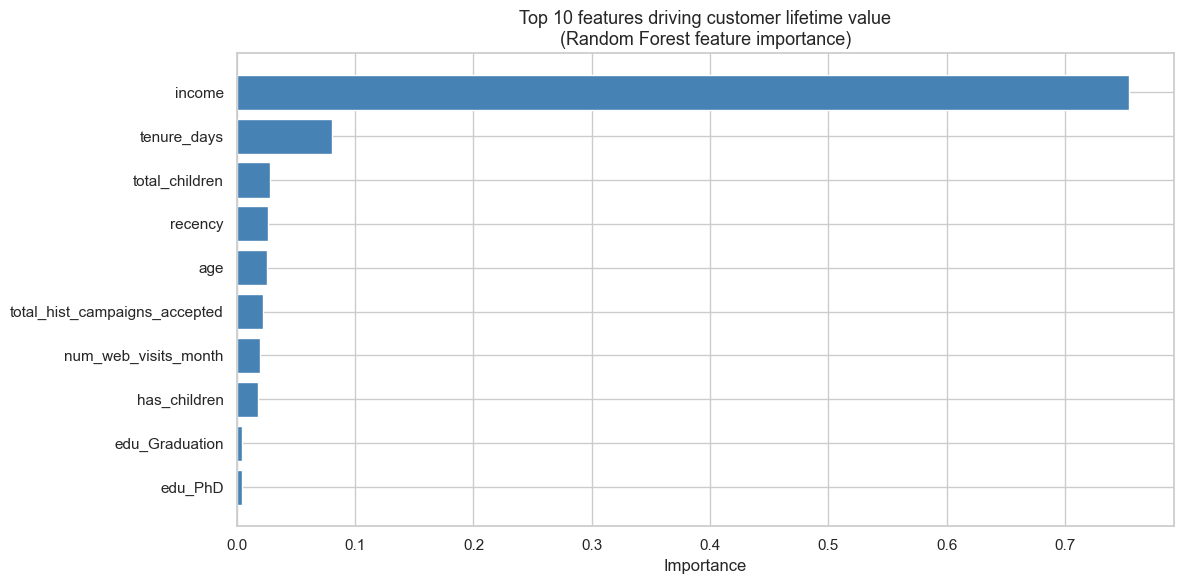

In [10]:
# Use the winning model's importance if available, otherwise coefficients
if hasattr(best_reg_model, 'feature_importances_'):
    importance = best_reg_model.feature_importances_
    importance_label = f'{best_reg_name} feature importance'
elif hasattr(best_reg_model, 'coef_'):
    importance = np.abs(best_reg_model.coef_)
    importance_label = f'{best_reg_name} |coefficient|'
else:
    importance = np.zeros(len(clv_features))
    importance_label = 'N/A'

importance_df = pd.DataFrame({
    'Feature':    clv_features,
    'Importance': importance,
}).sort_values('Importance', ascending=False)

print(f'Top features driving CLV ({importance_label}):')
print(importance_df.head(10).to_string(index=False))

importance_df.to_csv(os.path.join(PROCESSED_PATH, 'clv_feature_importance.csv'), index=False)

# Visualise top 10
top10 = importance_df.head(10)
plt.figure(figsize=(12, 6))
plt.barh(top10['Feature'][::-1], top10['Importance'][::-1], color='steelblue')
plt.title(f'Top 10 features driving customer lifetime value\n({importance_label})', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p4_feature_importance.png'), dpi=150)
plt.show()

---
## 7. Campaign response classifier
**Target:** `response` (1 = accepted the latest campaign, 0 = did not).
**Class imbalance:** ~15% positive — handled consistently across all three models with `sample_weight` so the comparison is apples-to-apples.

For the classifier we CAN use purchase counts and total spend as features — they're not leakage because we're predicting response, not spend. Behavioural signals are likely strong predictors of response.

**Evaluation order:** (1) confusion matrix per model — does the model actually catch responders? (2) full classification report (precision, recall, F1 per class) — is performance acceptable across both classes? (3) AUC-ROC — summary discrimination score, last.

In [11]:
# Classifier feature set — includes spend and purchase counts (not leakage for response)
clf_features = clv_features + ['total_spend',
                                'num_web_purchases', 'num_store_purchases',
                                'num_catalog_purchases', 'num_deals_purchases',
                                'total_purchases']

X_clf = df[clf_features].values
y_clf = df['response'].values

print(f'Classifier features ({len(clf_features)})')
print(f'Response rate: {y_clf.mean()*100:.2f}% positive ({y_clf.sum():,} of {len(y_clf):,})')

# Stratified 80/20 split so the test set keeps the same response rate as the full data
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Scale for Logistic Regression
scaler_clf = StandardScaler()
X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled  = scaler_clf.transform(X_clf_test)

# sample_weight applied at .fit() time gives every classifier the same imbalance handling.
# Logistic Regression and Random Forest also support class_weight='balanced' but
# Gradient Boosting doesn't — using sample_weight keeps the three models on equal footing.
sample_weights = compute_sample_weight(class_weight='balanced', y=y_clf_train)
print(f'\nSample weight ratio (positive : negative): '
      f'{sample_weights[y_clf_train == 1].mean():.2f} : {sample_weights[y_clf_train == 0].mean():.2f}')

Classifier features (22)
Response rate: 15.05% positive (333 of 2,212)

Sample weight ratio (positive : negative): 3.33 : 0.59


In [12]:
# Train all three classifiers + a stratified-random baseline
classifiers = {
    'Baseline (random)':   DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

trained_clf = {}
clf_metrics = []

print('Confusion matrices — step 1 of evaluation:')
print('=' * 60)

for name, clf in classifiers.items():
    is_linear = name in ('Baseline (random)', 'Logistic Regression')
    X_tr = X_clf_train_scaled if is_linear else X_clf_train
    X_te = X_clf_test_scaled  if is_linear else X_clf_test

    # Baseline doesn't take sample_weight
    if name == 'Baseline (random)':
        clf.fit(X_tr, y_clf_train)
    else:
        clf.fit(X_tr, y_clf_train, sample_weight=sample_weights)

    preds = clf.predict(X_te)
    proba = clf.predict_proba(X_te)[:, 1]

    cm = confusion_matrix(y_clf_test, preds)
    tn, fp, fn, tp = cm.ravel()
    recall_pos = recall_score(y_clf_test, preds, pos_label=1)
    recall_neg = recall_score(y_clf_test, preds, pos_label=0)
    acc = accuracy_score(y_clf_test, preds)
    auc = roc_auc_score(y_clf_test, proba)

    trained_clf[name] = (clf, X_te, preds, proba)
    clf_metrics.append({
        'Model':           name,
        'Recall (Respond)': round(recall_pos, 4),
        'Recall (Not)':     round(recall_neg, 4),
        'Accuracy':         round(acc, 4),
        'AUC-ROC':          round(auc, 4),
    })

    print(f'\n{name}:')
    print(f'                  Predicted-Not  Predicted-Respond')
    print(f'  Actual-Not        {tn:>6}        {fp:>6}')
    print(f'  Actual-Respond    {fn:>6}        {tp:>6}')

print()
print('=' * 60)
print('Per-model metrics — step 2 of evaluation:')
clf_metrics_df = pd.DataFrame(clf_metrics)
print(clf_metrics_df.to_string(index=False))

Confusion matrices — step 1 of evaluation:

Baseline (random):
                  Predicted-Not  Predicted-Respond
  Actual-Not           318            58
  Actual-Respond        57            10

Logistic Regression:
                  Predicted-Not  Predicted-Respond
  Actual-Not           309            67
  Actual-Respond        17            50

Random Forest:
                  Predicted-Not  Predicted-Respond
  Actual-Not           370             6
  Actual-Respond        49            18

Gradient Boosting:
                  Predicted-Not  Predicted-Respond
  Actual-Not           320            56
  Actual-Respond        21            46

Per-model metrics — step 2 of evaluation:
              Model  Recall (Respond)  Recall (Not)  Accuracy  AUC-ROC
  Baseline (random)            0.1493        0.8457    0.7404   0.4975
Logistic Regression            0.7463        0.8218    0.8104   0.8821
      Random Forest            0.2687        0.9840    0.8758   0.8722
  Gradient Boosting 

### 7a. Model selection — per-class recall first, AUC-ROC second
The headline rule: don't pick the model with the highest AUC if it can't catch the minority class. For a campaign-targeting use case, **recall on the Respond class is the metric that matters most** — missing a responder is a direct revenue loss. We accept some false positives if it gets us a high responder recall.

In [13]:
# Pick the best non-baseline classifier by (recall on Respond, then AUC-ROC)
candidates = clf_metrics_df[clf_metrics_df['Model'] != 'Baseline (random)'].copy()
candidates = candidates.sort_values(
    by=['Recall (Respond)', 'AUC-ROC'], ascending=[False, False]
)

print('Candidate ranking by (Recall on Respond → AUC-ROC):')
print(candidates.to_string(index=False))

best_clf_name = candidates.iloc[0]['Model']
best_clf, X_te_clf, best_clf_preds, best_clf_proba = trained_clf[best_clf_name]

print(f'\n→ Selected classifier: {best_clf_name}')
print(f'   Recall on Respond:    {candidates.iloc[0]["Recall (Respond)"]:.4f}')
print(f'   AUC-ROC:              {candidates.iloc[0]["AUC-ROC"]:.4f}')

Candidate ranking by (Recall on Respond → AUC-ROC):
              Model  Recall (Respond)  Recall (Not)  Accuracy  AUC-ROC
Logistic Regression            0.7463        0.8218    0.8104   0.8821
  Gradient Boosting            0.6866        0.8511    0.8262   0.8790
      Random Forest            0.2687        0.9840    0.8758   0.8722

→ Selected classifier: Logistic Regression
   Recall on Respond:    0.7463
   AUC-ROC:              0.8821


In [14]:
# Step 2 — full classification report for the selected model
print(f'Classification report — {best_clf_name}:')
print()
print(classification_report(
    y_clf_test, best_clf_preds,
    target_names=['Not respond', 'Respond'], digits=4
))

Classification report — Logistic Regression:

              precision    recall  f1-score   support

 Not respond     0.9479    0.8218    0.8803       376
     Respond     0.4274    0.7463    0.5435        67

    accuracy                         0.8104       443
   macro avg     0.6876    0.7840    0.7119       443
weighted avg     0.8691    0.8104    0.8294       443



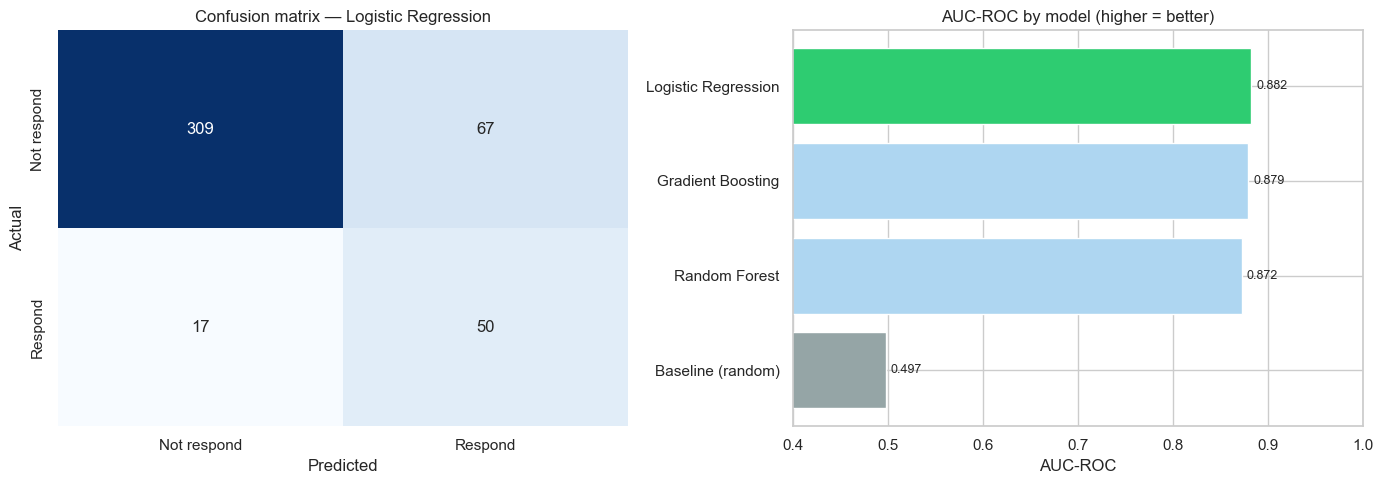

In [15]:
# Step 3 — visualise confusion matrix + ROC summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_best = confusion_matrix(y_clf_test, best_clf_preds)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not respond', 'Respond'],
            yticklabels=['Not respond', 'Respond'],
            ax=axes[0], cbar=False)
axes[0].set_title(f'Confusion matrix — {best_clf_name}', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# AUC-ROC bar comparison across all models including baseline
order = clf_metrics_df.sort_values('AUC-ROC', ascending=True)
auc_colors = ['#2ECC71' if m == best_clf_name else
              '#95A5A6' if m == 'Baseline (random)' else '#AED6F1'
              for m in order['Model']]
axes[1].barh(order['Model'], order['AUC-ROC'], color=auc_colors)
axes[1].set_title('AUC-ROC by model (higher = better)', fontsize=12)
axes[1].set_xlabel('AUC-ROC')
axes[1].set_xlim(0.4, 1.0)
for i, (_, row) in enumerate(order.iterrows()):
    axes[1].text(row['AUC-ROC'] + 0.005, i, f'{row["AUC-ROC"]:.3f}',
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p4_classifier_diagnostics.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Targeting priority matrix
Combine CLV tier (value) with response probability (likelihood) to identify the most efficient targeting segments. **High-value × high-probability customers are the top priority** — they're both likely to respond and worth the most when they do.

In [16]:
# Apply CLV tier (qcut for tertiles — matches NTILE(3) behaviour)
df['clv_tier_num'] = pd.qcut(df['total_spend'], q=3, labels=[1, 2, 3]).astype(int)
df['clv_tier'] = df['clv_tier_num'].map({1: 'Low value', 2: 'Mid value', 3: 'High value'})

# Compute response probability across the full dataset using the winning classifier
X_all = df[clf_features].values
X_all_input = (scaler_clf.transform(X_all)
               if best_clf_name in ('Baseline (random)', 'Logistic Regression')
               else X_all)
df['response_prob'] = best_clf.predict_proba(X_all_input)[:, 1]

# Aggregate by CLV tier
priority = df.groupby('clv_tier').agg(
    customer_count=('customer_id', 'count'),
    avg_spend=('total_spend', 'mean'),
    avg_response_prob=('response_prob', 'mean'),
    actual_response_rate=('response', 'mean'),
).round(3).reset_index()

# Order: High → Mid → Low
order_map = {'High value': 0, 'Mid value': 1, 'Low value': 2}
priority['_o'] = priority['clv_tier'].map(order_map)
priority = priority.sort_values('_o').drop(columns='_o')

print('Targeting priority matrix (highest value tier first):')
print(priority.to_string(index=False))

Targeting priority matrix (highest value tier first):
  clv_tier  customer_count  avg_spend  avg_response_prob  actual_response_rate
High value             737   1355.404              0.446                 0.251
 Mid value             736    416.139              0.297                 0.124
 Low value             739     51.510              0.237                 0.077


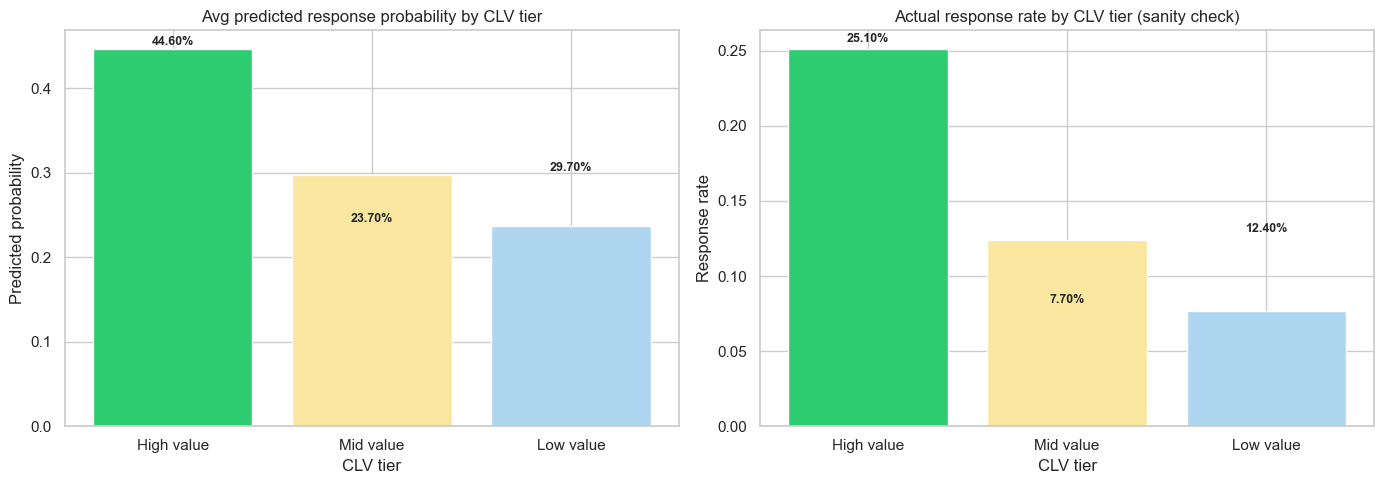

✅ clv_predictions.csv saved


In [17]:
# Visualise the priority matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg predicted response probability by tier
axes[0].bar(priority['clv_tier'], priority['avg_response_prob'],
            color=['#2ECC71', '#F9E79F', '#AED6F1'])
axes[0].set_title('Avg predicted response probability by CLV tier', fontsize=12)
axes[0].set_xlabel('CLV tier')
axes[0].set_ylabel('Predicted probability')
for i, row in priority.iterrows():
    axes[0].text(i, row['avg_response_prob'] + 0.005,
                 f'{row["avg_response_prob"]:.2%}',
                 ha='center', fontsize=9, fontweight='bold')

# Actual response rate by tier — sanity check that probability tracks reality
axes[1].bar(priority['clv_tier'], priority['actual_response_rate'],
            color=['#2ECC71', '#F9E79F', '#AED6F1'])
axes[1].set_title('Actual response rate by CLV tier (sanity check)', fontsize=12)
axes[1].set_xlabel('CLV tier')
axes[1].set_ylabel('Response rate')
for i, row in priority.iterrows():
    axes[1].text(i, row['actual_response_rate'] + 0.005,
                 f'{row["actual_response_rate"]:.2%}',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'p4_targeting_priority.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Persist per-customer predictions for Phase 6 / dashboard use
df[['customer_id', 'total_spend', 'clv_tier', 'response_prob', 'response']].to_csv(
    os.path.join(PROCESSED_PATH, 'clv_predictions.csv'), index=False
)
print('✅ clv_predictions.csv saved')

---
## 9. Phase 4 summary

In [18]:
best_r2  = reg_results_df.loc[reg_results_df['Model'] == best_reg_name, 'R²'].values[0]
best_mae = reg_results_df.loc[reg_results_df['Model'] == best_reg_name, 'MAE'].values[0]
baseline_r2 = reg_results_df.loc[reg_results_df['Model'] == 'Baseline (mean)', 'R²'].values[0]
best_auc = clf_metrics_df.loc[clf_metrics_df['Model'] == best_clf_name, 'AUC-ROC'].values[0]
best_recall_pos = clf_metrics_df.loc[clf_metrics_df['Model'] == best_clf_name, 'Recall (Respond)'].values[0]
best_recall_neg = clf_metrics_df.loc[clf_metrics_df['Model'] == best_clf_name, 'Recall (Not)'].values[0]
baseline_auc = clf_metrics_df.loc[clf_metrics_df['Model'] == 'Baseline (random)', 'AUC-ROC'].values[0]

high_prob = float(priority[priority['clv_tier'] == 'High value']['avg_response_prob'].values[0])
low_prob  = float(priority[priority['clv_tier'] == 'Low value']['avg_response_prob'].values[0])

print('=' * 64)
print('PHASE 4 SUMMARY — CLV & RESPONSE PROPENSITY')
print('=' * 64)
print()
print('--- CLV regression (leakage-free) ---')
print(f'Best model:                {best_reg_name}')
print(f'R²:                        {best_r2:.4f}    (baseline = {baseline_r2:.4f})')
print(f'MAE:                       ${best_mae:,.2f}')
print()
print('--- Response classifier ---')
print(f'Selected:                  {best_clf_name}')
print(f'Recall on Respond class:   {best_recall_pos:.4f}')
print(f'Recall on Not-respond:     {best_recall_neg:.4f}')
print(f'AUC-ROC:                   {best_auc:.4f}    (baseline = {baseline_auc:.4f})')
print()
print('--- Targeting ---')
print(f'High-value tier avg prob:  {high_prob:.2%}')
print(f'Low-value tier avg prob:   {low_prob:.2%}')
print(f'Implied lift:              {high_prob/max(low_prob,1e-6):.1f}× — high-value customers are')
print(f'                           dramatically more likely to respond than low-value ones.')
print()
print('--- Outputs ---')
print('  clv_feature_importance.csv — feature ranking from winning model')
print('  clv_predictions.csv        — CLV tier + response probability per customer')
print()
print('Key takeaway: response propensity is well-separated from CLV tier — high-value')
print('customers are both worth more AND more likely to respond. The targeting matrix is')
print('actionable as-is for Phase 6 and the dashboard.')
print('=' * 64)
print()
print('✅ Phase 4 complete. Proceed to Phase 5 — Sentiment analysis.')

PHASE 4 SUMMARY — CLV & RESPONSE PROPENSITY

--- CLV regression (leakage-free) ---
Best model:                Random Forest
R²:                        0.8594    (baseline = -0.0009)
MAE:                       $151.58

--- Response classifier ---
Selected:                  Logistic Regression
Recall on Respond class:   0.7463
Recall on Not-respond:     0.8218
AUC-ROC:                   0.8821    (baseline = 0.4975)

--- Targeting ---
High-value tier avg prob:  44.60%
Low-value tier avg prob:   23.70%
Implied lift:              1.9× — high-value customers are
                           dramatically more likely to respond than low-value ones.

--- Outputs ---
  clv_feature_importance.csv — feature ranking from winning model
  clv_predictions.csv        — CLV tier + response probability per customer

Key takeaway: response propensity is well-separated from CLV tier — high-value
customers are both worth more AND more likely to respond. The targeting matrix is
actionable as-is for Phase 6 an